In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

DATA_PATH = Path("../data/music_listeners (1).csv")
GRAPH_DIR = Path("../graphs")
GRAPH_DIR.mkdir(exist_ok=True)
plot_counter = 1


def save_plot():
    global plot_counter
    path = GRAPH_DIR / f"data{plot_counter}.png"
    plt.savefig(path, bbox_inches="tight", dpi=150)
    plot_counter += 1
    return path


if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset loaded successfully.
Dataset shape: (30, 4)
Columns: ['listening_hours_per_week', 'songs_per_day', 'skip_rate', 'playlist_count']


,listening_hours_per_week,songs_per_day,skip_rate,playlist_count
0,2,10,55,2
1,3,15,50,3
2,4,20,60,4
3,5,18,45,3
4,6,22,50,5


### 1. Load the music listener dataset

This cell imports the analysis libraries, loads the CSV file, creates the graphs output folder, and previews the dataset.

**Conclusion:** The dataset loads successfully with 30 listener records and four numeric behavior features, providing a compact basis for exploratory analysis and later segmentation.

In [14]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nSummary statistics:")
df.describe().T

Dataset shape: (30, 4)

Columns:
['listening_hours_per_week', 'songs_per_day', 'skip_rate', 'playlist_count']

Data types:
listening_hours_per_week    int64
songs_per_day               int64
skip_rate                   int64
playlist_count              int64
dtype: object

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
listening_hours_per_week,30.0,15.166667,10.796179,2.0,6.00,12.5,24.25,38.0
songs_per_day,30.0,60.433333,42.906220,10.0,22.50,49.0,93.75,145.0
skip_rate,30.0,29.466667,18.503929,3.0,12.75,29.0,45.00,65.0
playlist_count,30.0,14.966667,10.765473,2.0,5.00,14.5,21.50,40.0


### 2. Dataset overview

This cell reports the dataset dimensions, available columns, data types, and descriptive statistics so the structure and scale of each feature are clear.

**Conclusion:** All four variables are numeric and have different scales. Listening hours, songs per day, and playlist count measure engagement, while skip rate measures listening selectivity.

In [15]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique values per column:")
print(df.nunique())

Missing values:
listening_hours_per_week    0
songs_per_day               0
skip_rate                   0
playlist_count              0
dtype: int64

Duplicate rows:
0

Unique values per column:
listening_hours_per_week    24
songs_per_day               29
skip_rate                   22
playlist_count              20
dtype: int64


### 3. Data quality checks

This cell checks for missing values, duplicate rows, and the number of unique values in each feature before visualization or clustering.

**Conclusion:** The dataset contains no missing values and no duplicate rows, so it is ready for visualization and preprocessing without basic data-cleaning repairs.

Numeric columns: ['listening_hours_per_week', 'songs_per_day', 'skip_rate', 'playlist_count']

Correlation matrix:
                          listening_hours_per_week  songs_per_day  skip_rate  \
listening_hours_per_week                      1.00           1.00      -0.93   
songs_per_day                                 1.00           1.00      -0.93   
skip_rate                                    -0.93          -0.93       1.00   
playlist_count                                0.97           0.97      -0.92   

                          playlist_count  
listening_hours_per_week            0.97  
songs_per_day                       0.97  
skip_rate                          -0.92  
playlist_count                      1.00  
Saved plot: ..\graphs\data1.png


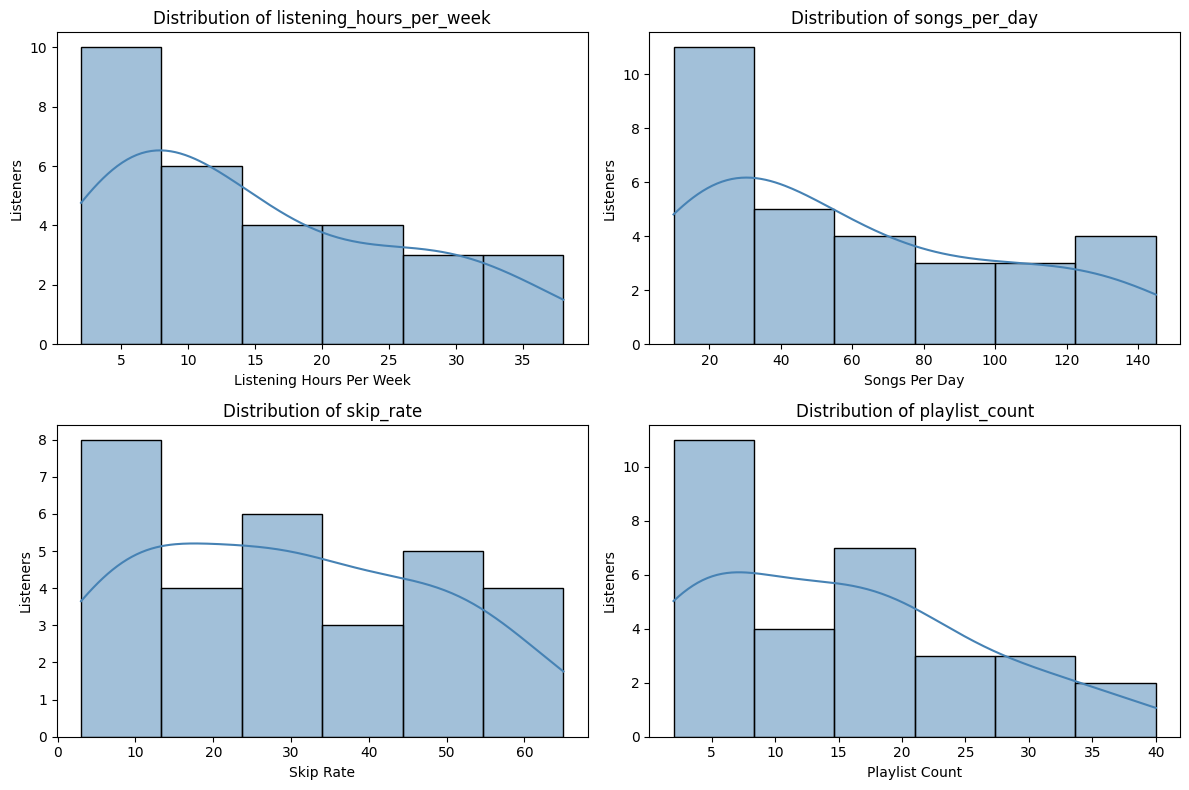

In [16]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns:", numeric_columns)
print("\nCorrelation matrix:")
print(df[numeric_columns].corr().round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, column in zip(axes.ravel(), numeric_columns):
    sns.histplot(data=df, x=column, kde=True, ax=axis, color="steelblue")
    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel(column.replace("_", " ").title())
    axis.set_ylabel("Listeners")
fig.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

### 4. Feature distributions

This cell uses Seaborn histograms and Matplotlib subplots to show the distribution of listening hours, songs per day, skip rate, and playlist count. The combined figure is displayed inline and saved to the graphs folder.

**Conclusion:** The features cover a broad range of listener behavior. Higher values are less frequent for several measures, so scaling the variables will be important before distance-based clustering.

Saved plot: ..\graphs\data2.png


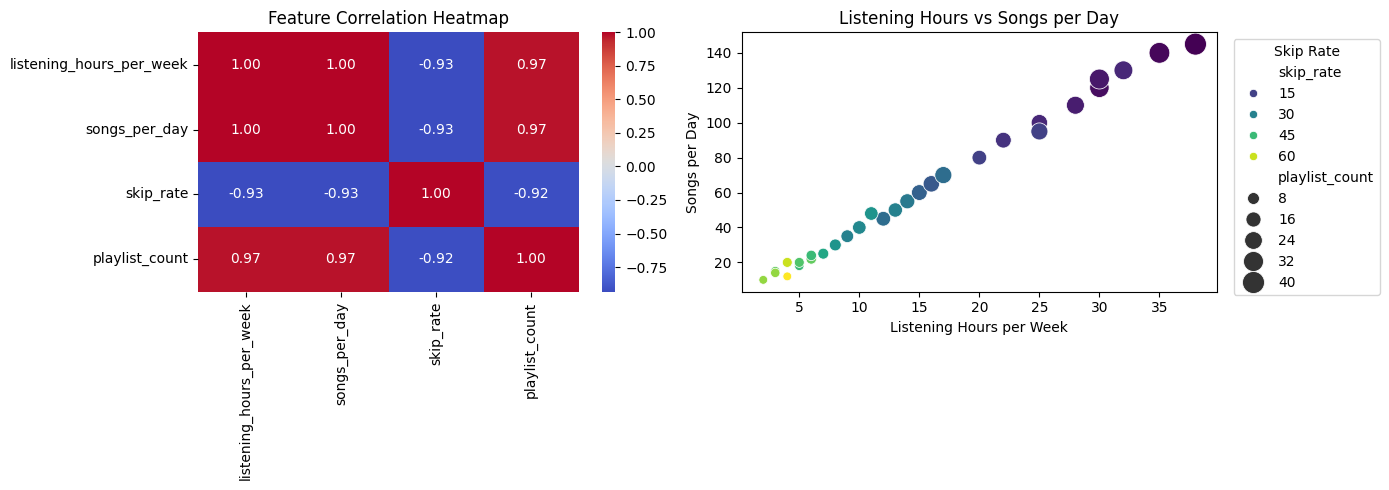


Pairwise relationships:
Saved plot: ..\graphs\data3.png


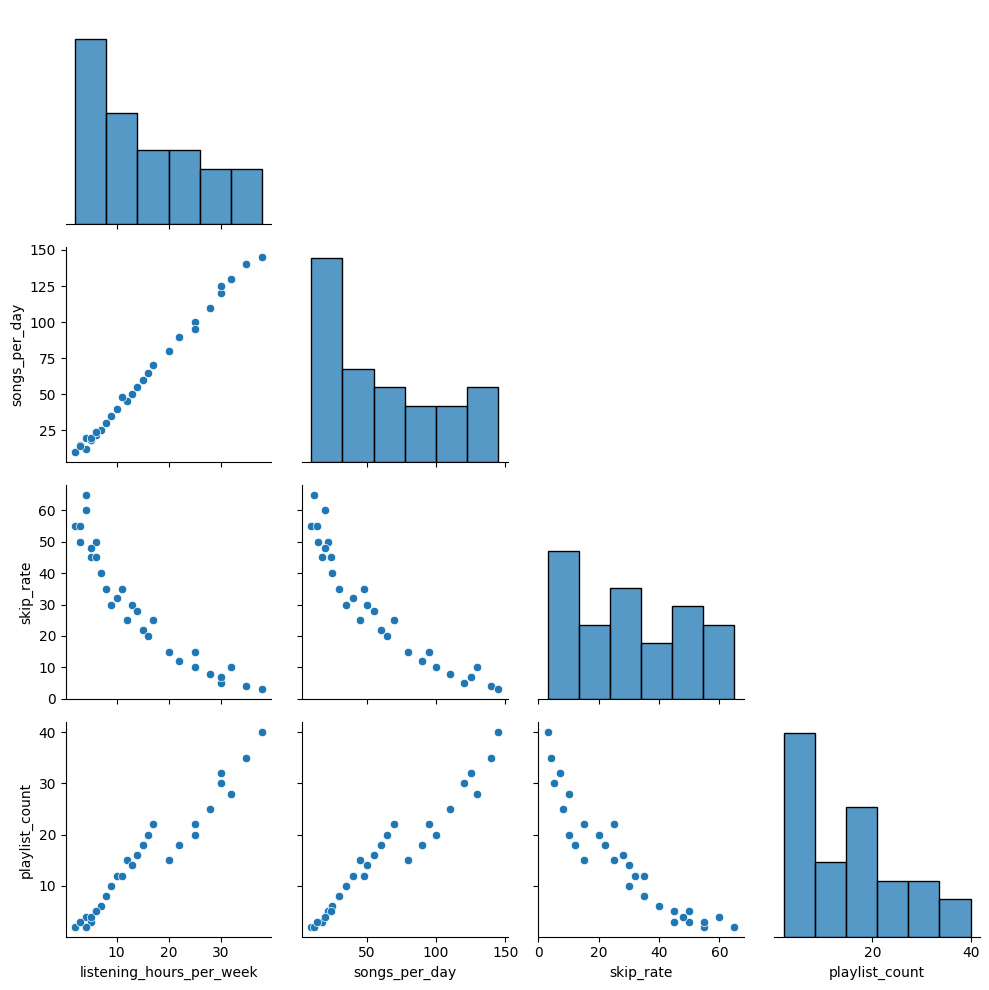

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0],
)
axes[0].set_title("Feature Correlation Heatmap")

sns.scatterplot(
    data=df,
    x="listening_hours_per_week",
    y="songs_per_day",
    size="playlist_count",
    hue="skip_rate",
    palette="viridis",
    sizes=(40, 250),
    ax=axes[1],
)
axes[1].set_title("Listening Hours vs Songs per Day")
axes[1].set_xlabel("Listening Hours per Week")
axes[1].set_ylabel("Songs per Day")
axes[1].legend(title="Skip Rate", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

print("\nPairwise relationships:")
pair_grid = sns.pairplot(df[numeric_columns], corner=True)
pair_grid.fig.tight_layout()
pair_path = GRAPH_DIR / f"data{plot_counter}.png"
pair_grid.fig.savefig(pair_path, bbox_inches="tight", dpi=150)
plot_counter += 1
print(f"Saved plot: {pair_path}")
plt.show()

### 5. Relationships and correlations

This cell visualizes feature correlations, compares listening hours with songs per day, and displays pairwise relationships to support later listener segmentation.

**Conclusion:** Listening hours, songs per day, and playlist count move together strongly, while skip rate moves in the opposite direction. This suggests a clear engagement pattern: highly active listeners tend to create more playlists and skip fewer songs. These relationships can help identify meaningful listener segments, but clustering should confirm the groups rather than assume them.